# 08 — Custom sentiment classifier

**Doel:** train je eigen sentiment-classifiers op de Kaggle pre-computed labels.
Dit is wat het verschil maakt tussen "wij hebben Kaggle gebruikt" en "wij hebben
onze eigen ML-pipeline gebouwd die kan reproduceren wat Kaggle scoort, en die
we ook op live data kunnen toepassen".

**Plan:**
1. Load Kaggle CSV met `sentiment_label` als target.
2. Chronologische train/test split (80/20).
3. Train drie classifiers:
   - **L1-Logistic** (sparse, interpretable) — baseline
   - **Random Forest** (non-linear, captures interactions) — baseline
   - **Twitter-RoBERTa** (modern transformer, pre-trained op social media tekst) — modern
4. Vergelijk op accuracy, macro-F1, per-class precision/recall, confusion matrix.
5. Interpretability: welke woorden voorspellen welke sentiment-klasse?
6. Save models voor gebruik in live-pipeline (fase 2/3 van het project).

**Thesis-defensie:** dit notebook bewijst dat je *zelf* kunt produceren wat
Kaggle pre-computed bevat. Kaggle wordt daarmee een **labeling-source** in
plaats van een analyse-engine.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score)

from src.data.preprocess import clean_text

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore")

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=3.0.2, numpy=2.4.4


## 1. Load Kaggle data met sentiment labels


In [2]:
raw = pd.read_csv("../data/raw/trump_truth_archive.csv", low_memory=False)
raw["created_at"] = pd.to_datetime(raw["created_at"], utc=True, format="ISO8601")
raw = raw.dropna(subset=["text", "sentiment_label"]).reset_index(drop=True)

print(f"Total posts with text + sentiment label: {len(raw):,}")
print(f"Date range: {raw['created_at'].min().date()} → {raw['created_at'].max().date()}")
print(f"\nClass distribution:")
print(raw["sentiment_label"].value_counts())
print((raw["sentiment_label"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")

Total posts with text + sentiment label: 26,819
Date range: 2022-02-14 → 2026-04-23

Class distribution:
sentiment_label
neutral     10827
positive     9813
negative     6179
Name: count, dtype: int64
sentiment_label
neutral     40.4%
positive    36.6%
negative    23.0%
Name: proportion, dtype: str


## 2. Chronological train/test split

Geen random shuffle — we willen testen of het model op *toekomstige* posts werkt
zonder dat het kennis heeft van die toekomst.


In [3]:
TEST_SIZE = 0.20

raw = raw.sort_values("created_at").reset_index(drop=True)
n_train = int(len(raw) * (1 - TEST_SIZE))

train = raw.iloc[:n_train].copy()
test = raw.iloc[n_train:].copy()

# Clean text
train["text_clean"] = train["text"].apply(clean_text)
test["text_clean"] = test["text"].apply(clean_text)

# Filter te-korte posts
train = train[train["text_clean"].str.split().str.len() >= 5].reset_index(drop=True)
test = test[test["text_clean"].str.split().str.len() >= 5].reset_index(drop=True)

print(f"Train: {len(train):,}  |  {train['created_at'].min().date()} → {train['created_at'].max().date()}")
print(f"Test:  {len(test):,}  |  {test['created_at'].min().date()} → {test['created_at'].max().date()}")
print()
print("Class distribution per split:")
print(pd.DataFrame({
    "train": train["sentiment_label"].value_counts(normalize=True).round(3),
    "test": test["sentiment_label"].value_counts(normalize=True).round(3),
}))

Train: 13,629  |  2022-02-14 → 2025-03-11
Test:  3,996  |  2025-03-11 → 2026-04-23

Class distribution per split:
                 train   test
sentiment_label              
positive         0.484  0.648
negative         0.365  0.265
neutral          0.151  0.087


## 3. TF-IDF features

Fit op train, transform op test. Geen leakage.


In [4]:
vectorizer = TfidfVectorizer(
    max_features=8000,        # ruimte voor de sentiment-relevante vocabulary
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True,
    stop_words="english",
)

X_train = vectorizer.fit_transform(train["text_clean"])
X_test = vectorizer.transform(test["text_clean"])

y_train = train["sentiment_label"].values
y_test = test["sentiment_label"].values

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Vocab:   {len(vectorizer.vocabulary_):,}")

X_train: (13629, 8000)
X_test:  (3996, 8000)
Vocab:   8,000


## 4. Train classifiers


In [5]:
results = {}

# Dummy baseline (stratified random)
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
results["dummy"] = dummy
print(f"dummy        accuracy={accuracy_score(y_test, dummy.predict(X_test)):.3f}")

# L1-Logistic (saga solver supports multi-class + L1)
print("Training L1-Logistic… (~2-5 min)")
logit = LogisticRegression(
    penalty="l1", C=1.0, solver="saga", max_iter=3000,
    random_state=42, class_weight="balanced", n_jobs=-1,
)
logit.fit(X_train, y_train)
results["logistic_l1"] = logit
print(f"logistic_l1  accuracy={accuracy_score(y_test, logit.predict(X_test)):.3f}")

# Random Forest
print("Training RF… (~3-8 min)")
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    min_samples_split=5, min_samples_leaf=2,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)
results["rf"] = rf
print(f"rf           accuracy={accuracy_score(y_test, rf.predict(X_test)):.3f}")

dummy        accuracy=0.424
Training L1-Logistic… (~2-5 min)
logistic_l1  accuracy=0.830
Training RF… (~3-8 min)
rf           accuracy=0.783


## 5. Metrics + confusion matrices


In [6]:
# Detailed metrics per model
for name, model in results.items():
    pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred, digits=3))


=== dummy ===
              precision    recall  f1-score   support

    negative      0.265     0.357     0.304      1057
     neutral      0.070     0.121     0.088       348
    positive      0.649     0.493     0.560      2591

    accuracy                          0.424      3996
   macro avg      0.328     0.323     0.317      3996
weighted avg      0.497     0.424     0.451      3996


=== logistic_l1 ===
              precision    recall  f1-score   support

    negative      0.804     0.723     0.761      1057
     neutral      0.490     0.876     0.629       348
    positive      0.927     0.867     0.896      2591

    accuracy                          0.830      3996
   macro avg      0.741     0.822     0.762      3996
weighted avg      0.856     0.830     0.837      3996


=== rf ===
              precision    recall  f1-score   support

    negative      0.717     0.632     0.672      1057
     neutral      0.457     0.851     0.594       348
    positive      0.897    

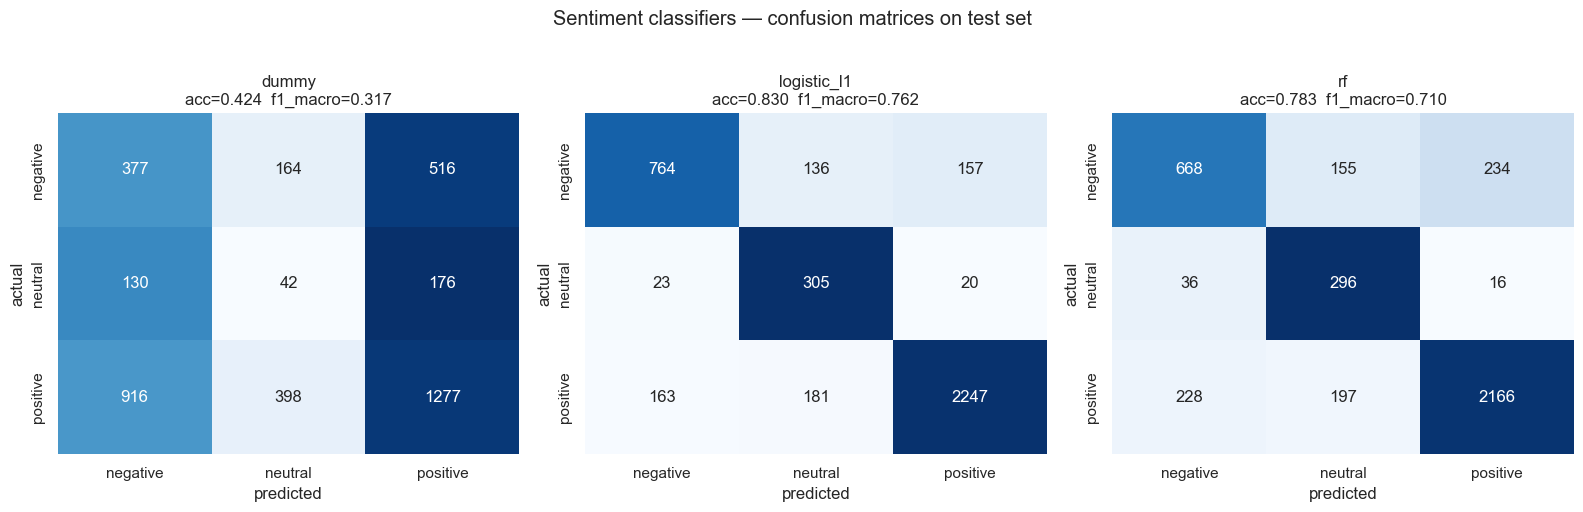

In [7]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = sorted(set(y_train))

for ax, (name, model) in zip(axes, results.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels,
                cbar=False, ax=ax)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    ax.set_title(f"{name}\nacc={acc:.3f}  f1_macro={f1:.3f}")
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")

fig.suptitle("Sentiment classifiers — confusion matrices on test set", y=1.02)
fig.tight_layout()
plt.show()

## 6. Optioneel: Twitter-RoBERTa transformer

`cardiffnlp/twitter-roberta-base-sentiment-latest` is een 125M-parameter transformer
pretrained op ~58M tweets en fine-tuned voor 3-class sentiment. Designed voor
social media tekst — passender dan FinBERT (dat voor financial text is).

**Setup**: vereist `pip install transformers torch` (zit al in pyproject.toml `[nlp]` extra).

**Run-tijd**: CPU ~20-40 min op 26k posts. Op M-chip Mac met `mps` backend: ~5-10 min.

**Als je het wil overslaan**: skip deze cellen en ga direct naar sectie 7. Je hebt
dan twee custom models (L1-Logistic + RF) — genoeg voor de scriptie. Transformer
kun je later toevoegen.


In [8]:
# Check of we transformer kunnen runnen
try:
    import torch
    from transformers import pipeline
    DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Transformer available. Device: {DEVICE}")
    TRANSFORMER_AVAILABLE = True
except ImportError:
    print("transformers/torch niet geïnstalleerd. Skip transformer cellen.")
    print("Installeer met:  pip install -e \".[nlp]\"")
    TRANSFORMER_AVAILABLE = False

Transformer available. Device: mps


In [9]:
# Run de transformer op de test set
if TRANSFORMER_AVAILABLE:
    print("Loading model… (eerste keer download ~500MB)")
    sentiment_pipe = pipeline(
        "sentiment-analysis",
        model="cardiffnlp/twitter-roberta-base-sentiment-latest",
        device=DEVICE,
        truncation=True,
        max_length=512,
    )

    # Twitter-RoBERTa label mapping (LABEL_0=negative, LABEL_1=neutral, LABEL_2=positive)
    LABEL_MAP = {"LABEL_0": "negative", "LABEL_1": "neutral", "LABEL_2": "positive",
                 "negative": "negative", "neutral": "neutral", "positive": "positive"}

    # Batch inference
    BATCH_SIZE = 32
    texts = test["text"].tolist()
    predictions = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i+BATCH_SIZE]
        outs = sentiment_pipe(batch)
        predictions.extend([LABEL_MAP.get(o["label"], o["label"]) for o in outs])
        if (i // BATCH_SIZE) % 20 == 0:
            print(f"  {i:,}/{len(texts):,}")

    test["pred_roberta"] = predictions
    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average="macro")
    print(f"\nTwitter-RoBERTa  accuracy={acc:.3f}  f1_macro={f1:.3f}")
    print()
    print(classification_report(y_test, predictions, digits=3))

Loading model… (eerste keer download ~500MB)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0/3,996
  640/3,996
  1,280/3,996
  1,920/3,996
  2,560/3,996
  3,200/3,996
  3,840/3,996

Twitter-RoBERTa  accuracy=0.686  f1_macro=0.594

              precision    recall  f1-score   support

    negative      0.610     0.685     0.646      1057
     neutral      0.251     0.563     0.347       348
    positive      0.897     0.702     0.788      2591

    accuracy                          0.686      3996
   macro avg      0.586     0.650     0.594      3996
weighted avg      0.765     0.686     0.712      3996



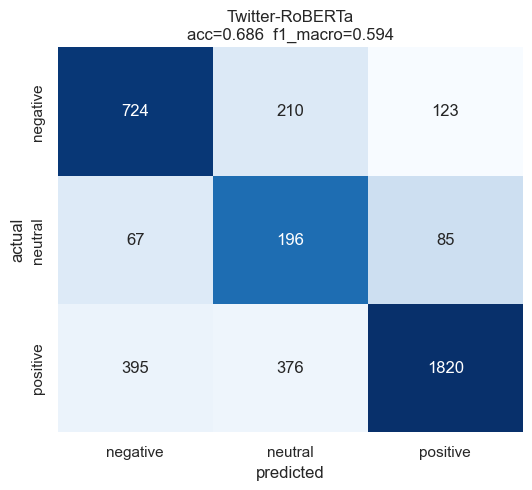

In [10]:
# Confusion matrix Twitter-RoBERTa
if TRANSFORMER_AVAILABLE:
    cm = confusion_matrix(y_test, test["pred_roberta"].values, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
    acc = accuracy_score(y_test, test["pred_roberta"].values)
    f1 = f1_score(y_test, test["pred_roberta"].values, average="macro")
    ax.set_title(f"Twitter-RoBERTa\nacc={acc:.3f}  f1_macro={f1:.3f}")
    ax.set_xlabel("predicted")
    ax.set_ylabel("actual")
    plt.show()

## 7. Vergelijking alle modellen


                 accuracy  f1_macro  f1_weighted
model                                           
dummy               0.424     0.317        0.451
logistic_l1         0.830     0.762        0.837
rf                  0.783     0.710        0.790
twitter_roberta     0.686     0.594        0.712


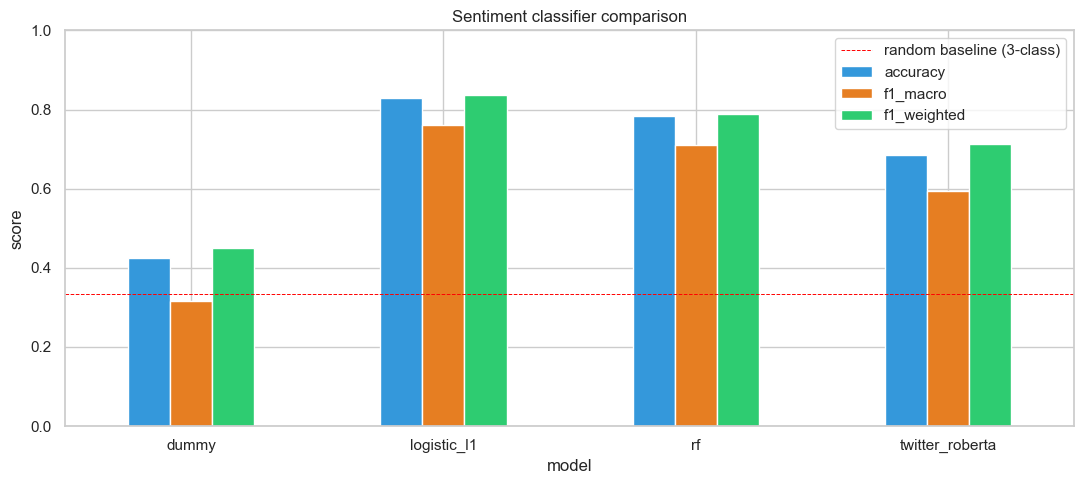

In [11]:
# Verzamel metrics in één tabel
summary_rows = []
for name, model in results.items():
    pred = model.predict(X_test)
    summary_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "f1_weighted": f1_score(y_test, pred, average="weighted"),
    })

if TRANSFORMER_AVAILABLE and "pred_roberta" in test.columns:
    summary_rows.append({
        "model": "twitter_roberta",
        "accuracy": accuracy_score(y_test, test["pred_roberta"].values),
        "f1_macro": f1_score(y_test, test["pred_roberta"].values, average="macro"),
        "f1_weighted": f1_score(y_test, test["pred_roberta"].values, average="weighted"),
    })

summary_df = pd.DataFrame(summary_rows).set_index("model").round(3)
print(summary_df)

# Bar chart vergelijking
fig, ax = plt.subplots(figsize=(11, 5))
summary_df.plot(kind="bar", ax=ax, color=["#3498db", "#e67e22", "#2ecc71"])
ax.set_title("Sentiment classifier comparison")
ax.set_ylabel("score")
ax.set_xticklabels(summary_df.index, rotation=0)
ax.set_ylim(0, 1)
ax.axhline(0.333, color="red", linewidth=0.7, linestyle="--", label="random baseline (3-class)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Interpretability: top features per class

Welke woorden zijn karakteristiek voor `positive`, `negative`, `neutral`?


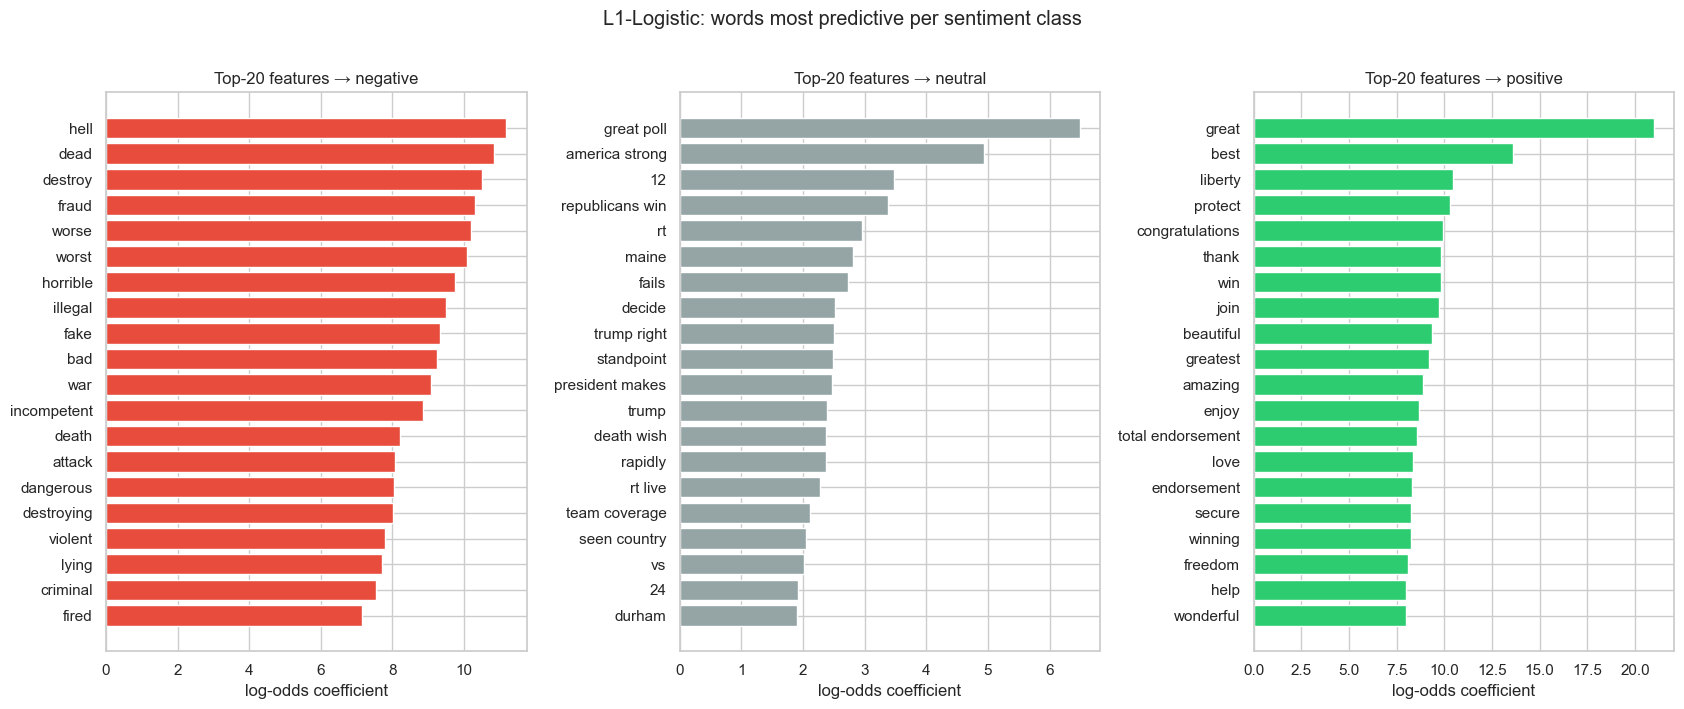

In [12]:
# L1-Logistic coefficients per class (sparse, interpretable)
feature_names = np.array(vectorizer.get_feature_names_out())
classes = logit.classes_

fig, axes = plt.subplots(1, 3, figsize=(17, 7))
for ax, cls, color in zip(axes, classes, ["#e74c3c", "#95a5a6", "#2ecc71"]):
    idx = list(classes).index(cls)
    coefs = logit.coef_[idx]
    top_idx = np.argsort(coefs)[::-1][:20]
    ax.barh(feature_names[top_idx][::-1], coefs[top_idx][::-1], color=color, edgecolor="white")
    ax.set_title(f"Top-20 features → {cls}")
    ax.set_xlabel("log-odds coefficient")

fig.suptitle("L1-Logistic: words most predictive per sentiment class", y=1.01)
fig.tight_layout()
plt.show()

## 9. Save trained models

Voor gebruik in fase 2 (live scraper) en fase 3 (dashboard).


In [13]:
models_dir = Path("../models/sentiment")
models_dir.mkdir(parents=True, exist_ok=True)

# Save vectorizer
joblib.dump(vectorizer, models_dir / "vectorizer.joblib")

# Save models
joblib.dump(results["logistic_l1"], models_dir / "logistic_l1.joblib")
joblib.dump(results["rf"], models_dir / "rf.joblib")

# Save metadata
metadata = {
    "task": "sentiment_classification",
    "n_classes": 3,
    "classes": list(classes),
    "train_size": len(train),
    "test_size": len(test),
    "cutoff_date": train["created_at"].max().isoformat(),
    "metrics": summary_df.to_dict(),
    "kaggle_label_column": "sentiment_label",
    "features": {
        "vectorizer": "TfidfVectorizer(max_features=8000, ngram=(1,2), min_df=5, stop_words=english)",
        "n_features": X_train.shape[1],
    },
}
import json
with open(models_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Saved to {models_dir.resolve()}:")
for p in sorted(models_dir.iterdir()):
    print(f"  {p.name:25s}  {p.stat().st_size:>10,} bytes")

Saved to /Users/quintenfriederichs/code/truthsocial-marketimpact/models/sentiment:
  logistic_l1.joblib            193,039 bytes
  metadata.json                     802 bytes
  rf.joblib                  43,486,609 bytes
  vectorizer.joblib             315,431 bytes
